# Classification : Logistic Regression with Regularization

In this lecture, we use logistic regression for classification involving feature engineering,  overfitting 

For visualization purposes 

In [5]:
import warnings
warnings.filterwarnings('ignore')     # 모든 경고 무시해줍니다... 

%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns

additional libraries

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures # 기본적으로 2차원에서 원 같은 line을 만들 수 없다. 그래서 ploynomials를 이용해서 원 같은 곡선 모양의 hyperplane을 만든다.
from sklearn.linear_model import LogisticRegression
# 아래의 라이브러리는 나중에 설명하겠습니다. (오늘 강의에서 사용하지 않습니다)
#from sklearn.linear_model import LogisticRegressionCV
#from sklearn.model_selection import cross_val_score, StratifiedKFold
#from sklearn.model_selection import GridSearchCV    <- 나중에 사용합니다. 

마이크로칩 테스팅 하는 데이터를 사용합니다. 본 데이터를 간략히 설명하면, 마이크로칩을 생산하여 검수를 test 1과 test 2를 수행하여, 품질의 합격/불합격을 결정한 데이터를 갖고 있습니다. (물론 더 많은 검수 과정을 거치겠지요?)



We use microchip test dataset, which goes to 2 tests for product evaluation.  

Let's use pandas

In [7]:
data = pd.read_csv('microchip_tests.txt',
                   header=None, names = ('test1','test2','released'))
data.head()

,test1,test2,released
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


Let's check the number of samples and its dimension

In [8]:
data.shape

(118, 3)

Let's split the raw data in to features and lables

In [9]:
X = data.iloc[:,:2].values
y = data.iloc[:,2].values


Let's use scatter plot for visualization 

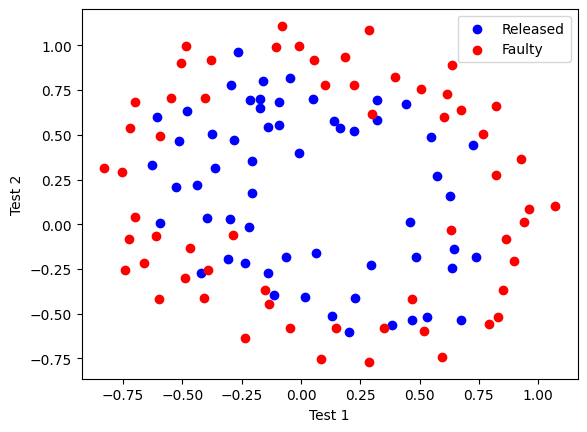

In [10]:
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Released')
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Faulty')
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.legend();

Let's define plot_boundary function for later use

In [11]:
def plot_boundary(clf, X, y, grid_step=.01, poly_featurizer=None):
    x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
    y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step),
                         np.arange(y_min, y_max, grid_step))

    Z = clf.predict(poly_featurizer.transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, cmap=plt.cm.Paired)



Let's use logistic regression directly to the dataset

Let's see how logistic regression performs

split the training and testing

In [12]:
from sklearn.model_selection  import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)


In [13]:
logit = LogisticRegression(C=10000.0)
logit.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10000.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

let's look at the decision boundary

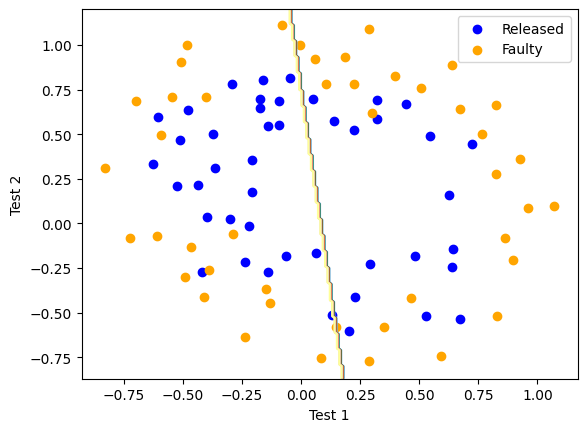

In [14]:
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', label='Released')
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='orange', label='Faulty')
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.legend();

#######################decision boundary plot 하는 부분 #################
clf =logit
grid_step=.01
x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step),
                     np.arange(y_min, y_max, grid_step))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, cmap=plt.cm.Paired)


We can see the model performs bad. lets look at the accuracy

In [15]:
print("Accuracy on training set:", 
      round(logit.score(X_train, y_train), 3))


Accuracy on training set: 0.591


## Feature Engineering

We had 2 features. that was our best shot!

Feature를 더 만들을 수는 없을까요? 

시각화 했을 때, decision boundary가 타원형이면 더 좋겠다는 생각은 안 했나요?
When visualizing the data, did you see that the results could have been better if the decision boundary was oval?

그렇다면 feature를 더 만드는 것은 어떨까요?    
Let's generates more features

x값을 제곱한 것을 만드는 것은 어떨까요? 

더 정확히   $x_1$, $x_2$ 가 있었을 때, $x_1$, $x_2$, $x_1^2$, $x_2^2$, $x_1 x_2$의 값을 더 만들어 보는 것은 어떨까요?

PolynomialFeatures does it for you :) 

In [22]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_train.shape

(88, 6)

이제 이 feature들을 이용하여 기존 모델을 개선해봅시다.
Let's try to improve the previous approach

Accuracy on training set: 0.841


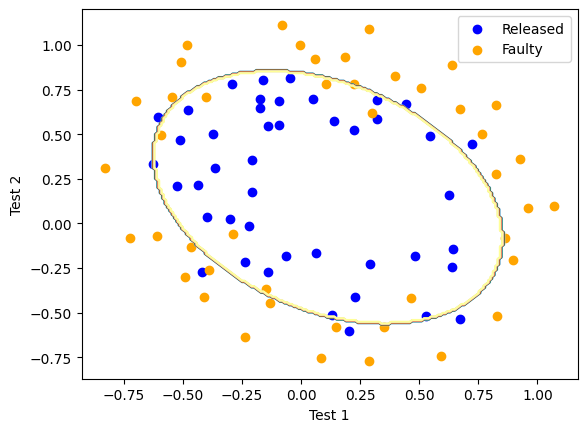

In [23]:
logit = LogisticRegression(C=10000.0)
logit.fit(X_poly_train, y_train)

plot_boundary(logit, X_train, y_train, grid_step=.01, poly_featurizer=poly)

plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', label='Released')
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='orange', label='Faulty')
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.legend();

print("Accuracy on training set:", 
      round(logit.score(X_poly_train, y_train), 3))


훨씬 나은 결과 값을 볼 수 있습니다. accuracy 또한 향상되었습니다.

If we have more features, we can get better results! 
how about we increase the degree and see the results? 

Accuracy on training set: 0.864


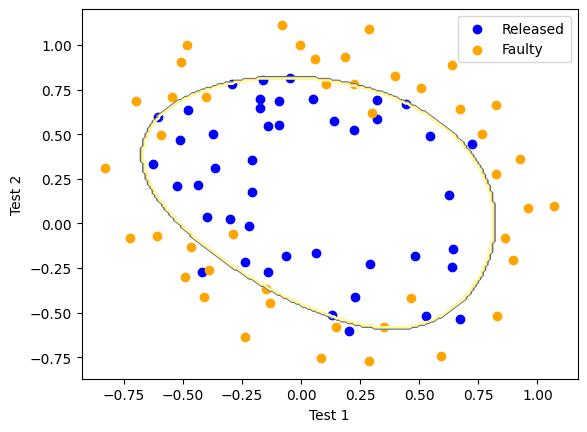

In [19]:
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X_train)

logit = LogisticRegression(C=10000.0)
logit.fit(X_poly, y_train)

plot_boundary(logit, X_train, y_train, grid_step=.01, poly_featurizer=poly)

plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', label='Released')
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='orange', label='Faulty')
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.legend();

print("Accuracy on training set:", 
      round(logit.score(X_poly, y_train), 3))


더 개선되었습니다! 

## Overfitting

Let's try degree 50
이제 polynomial feature를 degree 50으로 높여 해보도록 합시다.

ValueError: X has 6 features, but LogisticRegression is expecting 1326 features as input.

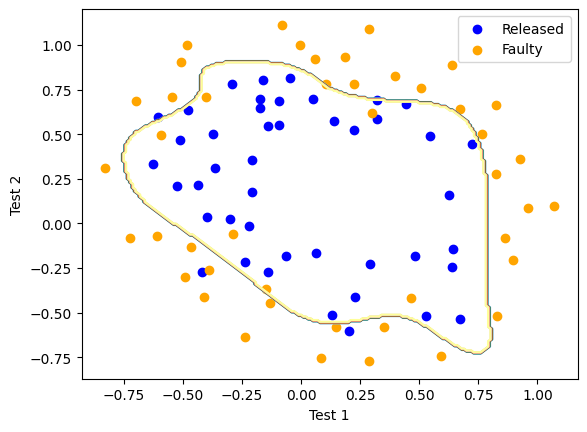

In [24]:
poly = PolynomialFeatures(degree=50)
X_poly = poly.fit_transform(X_train)

logit = LogisticRegression(C=10000.0)
logit.fit(X_poly, y_train)

plot_boundary(logit, X_train, y_train, grid_step=.01, poly_featurizer=poly)

plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', label='Released')
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='orange', label='Faulty')
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.legend();

print("Accuracy on training set:", 
      round(logit.score(X_poly_train, y_train), 3))

실행시간도 오래걸렸지만, 상당히 만족스러운 결과가 나온 것을 확인할 수 있습니다. 시간을 투자하여 fitting한 보람이 있는 만큼... 
그러나 decision boundary가 상당히 어색하며, 억지로 끼워넣은 듯한 모습입니다. 

We get better results on the training set. 
However, the decision boundary doesn't look natural. 



그렇다면, testing 데이터에 본 결과를 적용해보도록 합시다. 

In [25]:
X_poly_test = poly.fit_transform(X_test)
y_pred=logit.predict(X_poly_test)
print("Accuracy on testing set:", 
      round(logit.score(X_poly_test, y_test), 3))

Accuracy on testing set: 0.767


그 높던 accuracy 값이 0.733 으로 깎인 것을 확인할 수 있습니다! 

그렇다면, 직관적으로 그림을 봤을 때, 2차원에서 제일 잘 된 느낌을 받았는데, 그것을 적용해보는 것은 어떤가 확인해봅시다. (물론 training의 결과 값이 그리 만족 스럽지 않지만...)

Accuracy on training set: 0.841
Accuracy on testing set: 0.867


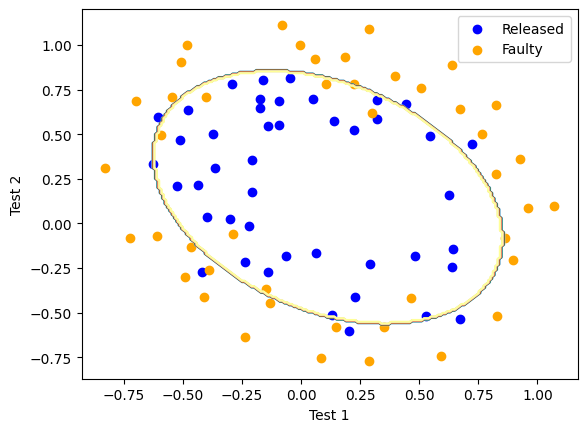

In [26]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)

logit = LogisticRegression(C=10000.0)
logit.fit(X_poly, y_train)

plot_boundary(logit, X_train, y_train, grid_step=.01, poly_featurizer=poly)

plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', label='Released')
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='orange', label='Faulty')
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.legend();

print("Accuracy on training set:", 
      round(logit.score(X_poly, y_train), 3))

X_poly_test = poly.fit_transform(X_test)
y_pred=logit.predict(X_poly_test)
print("Accuracy on testing set:", 
      round(logit.score(X_poly_test, y_test), 3))

만족스러운 testing 값이 나왔습니다. 

이것을 overfitting 이라고 합니다. training 할 때, 데이터에 너무 집중하여 최적하 한 것이 오히려 독이 되는 경우. 그렇다면, overfitting 을 방지하는 방법은 무엇이 있을까요?

We call this overfitting. How can we prevent overfitting? 

## Logistic Regression Regularization

$J(w) = \left[\sum_i^n -y^{(i)}log(\phi(z^{(i)})-(1-y^{(i)})log(1-\phi(z^{(i)})) \right] + \frac {\lambda}{2} {\Vert w \Vert}^2$

regularization 은 모든 feature를 고려하되, 의미가 없는 feature의 weight가 0에 가깝게 penalty를 적용하는 수식입니다. 
위는 ridge regression이라고 합니다.

그렇다면, 아까 degree 50 으로 하였던 케이스에 ridge regression을 적용해봅시다.

In [ ]:
poly = PolynomialFeatures(degree=50)
X_poly = poly.fit_transform(X_train)

logit = LogisticRegression(penalty='l2', C=10)          ##  l2 가 ridge   (C는 ]lambda의 역수라고 생각하면 됨)
logit.fit(X_poly, y_train)

plot_boundary(logit, X_train, y_train, grid_step=.01, poly_featurizer=poly)

plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', label='Released')
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='orange', label='Faulty')
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.legend();

print("Accuracy on training set:", 
      round(logit.score(X_poly, y_train), 3))

50개의 feature 인데도, 아까와 다른 decision boundary인 것을 확인할 수 있습니다. (상당히 스무스 합니다)

In [ ]:
X_poly_test = poly.fit_transform(X_test)
y_pred=logit.predict(X_poly_test)
print("Accuracy on testing set:", 
      round(logit.score(X_poly_test, y_test), 3))

testing한 결과를 보면, 상당히 만족스러운 것을 확인할 수 있습니다! 